# Local environments and electronic structure

Two questions a composition vector provably cannot answer.

**What does an atom's neighbourhood look like?** Octahedral or tetrahedral,
four-fold or six-fold, rigid or distorted. Two polymorphs have identical
compositions and can differ entirely in coordination — which is why `X` is
silent on the question and `mv.env` exists.

**What can the electrons do?** Almost every functional property is downstream
of the band structure, and a band structure is neither one number per material
nor one number per atom. It gets its own axis, and `mv.elec` builds it.

Both namespaces put results where their *shape* belongs, which is the thread
running through all of matverse: per-atom to the sites axis, per-band to the
bands axis, per-material scalars back to `obs` where a screen can reach them.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.18   🧮 Functions: 155   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



That report is the point of `mv.pl.set_style` doing more than set rcParams:
matverse ships one working calculator and dispatches the rest to whatever you
installed, so *which levels of theory can this machine run* has a different
answer on every machine — and it decides what the session can do.

## Loading a dataset

Olivine LiFePO₄, the cathode of [Padhi et al.
(1997)](https://doi.org/10.1149/1.1837571). Its structure is the textbook case
for the first half of this page: a framework of LiO₆ and FeO₆ octahedra with
rigid PO₄ tetrahedra wedged between them.

In [2]:
md = mv.datasets.load("battery_cathodes")[:1].copy()
mv.pp.describe(md)

md.obs[["name", "formula", "spacegroup", "nsites"]]

,name,formula,spacegroup,nsites
0,LiFePO4,LiFePO4,P2_1/c,28


## Coordination: the sites axis again

A coordination number is one value per atom, so it belongs on the axis whose
rows are atoms — the same object `mv.calc.forces` writes into.

In [3]:
sites = mv.multi.sites(md)
mv.env.coordination(md, sites)

sites.obs.groupby("element", observed=True)[
    "coordination_number"].mean().round(2)

element
Fe    6.0
Li    6.0
O     4.0
P     4.0
Name: coordination_number, dtype: float64

**Li 6, Fe 6, P 4, O 4** — the published olivine coordination, recovered from
the coordinates alone.

Which algorithm produced those numbers is recorded next to them, and that is
not bookkeeping. Near-neighbour algorithms disagree: CrystalNN and
MinimumDistanceNN routinely differ by one or two on the same site, so a
coordination number without its strategy is not reproducible.

In [4]:
mv.env.STRATEGIES

{'crystalnn': 'CrystalNN — Voronoi with a solid-angle cutoff tuned on the Materials Project; the general-purpose default',
 'voronoi': 'VoronoiNN — raw Voronoi solid angles, no chemistry-aware weighting',
 'minimum_distance': 'MinimumDistanceNN — everything within a tolerance of the shortest bond; fast and crude',
 'econ': 'EconNN — the effective coordination number of Hoppe (1979), which weights neighbours continuously rather than counting them',
 'brunner': 'BrunnerNN_real — the largest gap in the distance histogram'}

In [5]:
other = mv.multi.sites(md)
mv.env.coordination(md, other, strategy="minimum_distance")

pd.DataFrame({
    "crystalnn": sites.obs.groupby("element", observed=True)[
        "coordination_number"].mean(),
    "minimum_distance": other.obs.groupby("element", observed=True)[
        "coordination_number"].mean(),
}).round(2)

,crystalnn,minimum_distance
element,,
Fe,6.0,5.0
Li,6.0,6.0
O,4.0,1.0
P,4.0,4.0


## A number is not a shape

Six-fold coordination can be octahedral, trigonal prismatic, or a badly
distorted octahedron, and those are different materials. `mv.env.chemenv` fits
model polyhedra and reports the **continuous symmetry measure**: zero is
perfect, and a large value means "distorted" rather than the name it was
given.

In [6]:
mv.env.chemenv(md, sites)

sites.obs[["element", "environment", "environment_csm"]].head(12).round(2)

,element,environment,environment_csm
0:0,Li,O:6,2.07
0:1,Li,O:6,2.05
0:2,Li,O:6,2.08
0:3,Li,O:6,2.04
0:4,Fe,O:6,2.37
0:5,Fe,O:6,2.37
0:6,Fe,O:6,2.37
0:7,Fe,O:6,2.37
0:8,P,T:4,0.14
0:9,P,T:4,0.14


In [7]:
sites.obs.groupby("element", observed=True)[
    "environment_csm"].mean().round(3)

element
Fe    2.369
Li    2.060
O     2.160
P     0.140
Name: environment_csm, dtype: float64

This is the structural story of an olivine cathode, in one column.

The phosphate tetrahedron comes out at **0.14** — essentially a perfect T:4,
which is what a covalent polyanion is. The metal octahedra come out at
**2.0–2.4**, heavily distorted. That contrast is why LiFePO₄ is thermally
stable and safe while layered oxides are not: the P–O bonds do not let go, and
the framework does not collapse when lithium leaves.

A coordination number of 6 and 4 could not have told you that.

Text(0.5, 1.0, 'rigid phosphate, distorted metal octahedra')

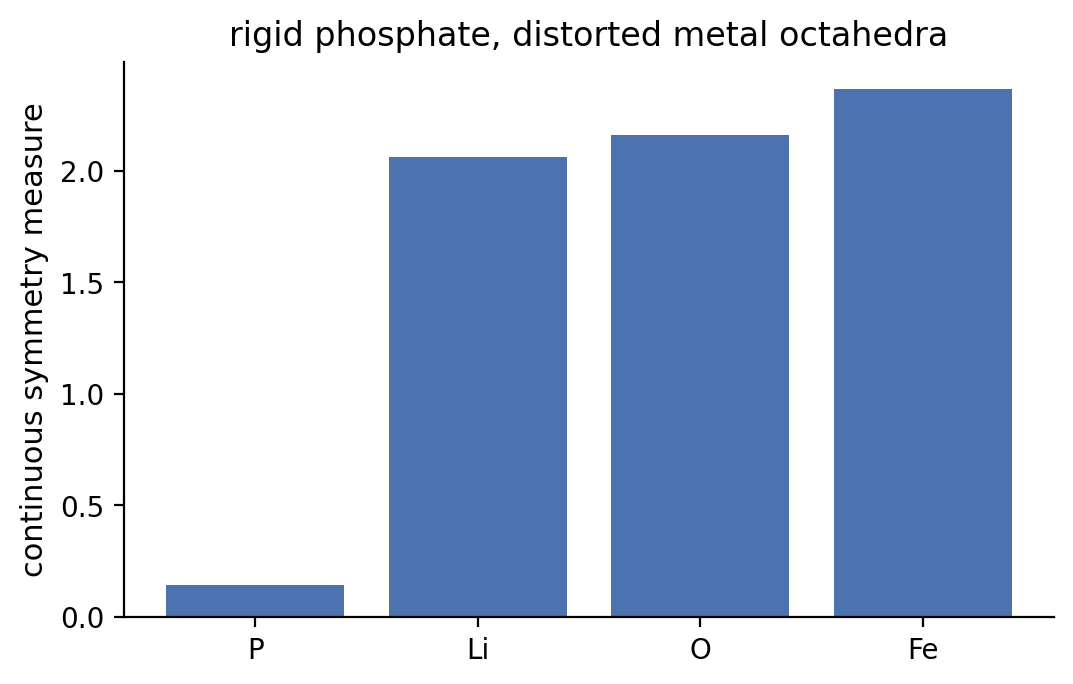

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.6))
by_element = sites.obs.groupby("element", observed=True)["environment_csm"]
order = by_element.mean().sort_values()
ax.bar(order.index, order.to_numpy(), color="#4c72b0")
ax.set_ylabel("continuous symmetry measure")
ax.set_title("rigid phosphate, distorted metal octahedra")

## The bond network belongs in `obsp`

Connectivity over the atoms is a graph over the rows of the sites object, and
AnnData already has a slot for exactly that — the same one a kNN graph occupies
in single-cell analysis.

In [9]:
mv.env.bonds(md, sites)

sites.obsp["bonds"].shape, sites.obsp["bonds"].nnz

((28, 28), 128)

In [10]:
degree = np.asarray(sites.obsp["bonds"].sum(axis=1)).ravel()
np.allclose(degree, sites.obs["coordination_number"].to_numpy(dtype=float))

True

The degree of the graph is the coordination number, which it had better be.

Bonds never cross materials — two atoms in different structures are never
connected — so the matrix is block diagonal and a graph algorithm cannot walk
from one material into another.

## Back to the material axis

Per-atom detail stays on the sites object; a screen needs a summary.

In [11]:
mv.env.summarise(sites, md)

md.obs[["name", "mean_coordination", "min_coordination",
        "max_coordination", "coordination_spread"]].round(2)

,name,mean_coordination,min_coordination,max_coordination,coordination_spread
0,LiFePO4,4.57,4.0,6.0,2.0


In [12]:
mv.screen.filter(md, max_coordination__ge=6.0, name="has_octahedra")
md.obs[["name", "has_octahedra"]]

,name,has_octahedra
0,LiFePO4,True


`coordination_spread` is the one worth screening on: zero means every atom sits
in the same environment, which is what a high-symmetry structure looks like
from the inside.

## The same graph, asked a global question

Coordination is local: how many neighbours does this atom have. The bond graph
also answers something the local view cannot — whether the structure holds
together in three directions, in two, in one, or not at all. That is the
difference between a framework, a layered material you can exfoliate, a chain
compound and a molecular crystal.

`mv.prop.dimensionality` is the archetypal thing `X` cannot tell you. Graphite
and diamond have the same composition matrix, the same `var`, and the same
element counts. One is layers held by van der Waals forces; the other is the
hardest material in common use.

In [13]:
from pymatgen.core import Lattice, Structure

graphite = Structure(Lattice.hexagonal(2.46, 6.70), ["C"] * 4,
                     [[0, 0, 0], [1/3, 2/3, 0], [0, 0, 0.5], [2/3, 1/3, 0.5]])
diamond = Structure(Lattice.cubic(3.567), ["C"] * 8,
                    [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0],
                     [.25, .25, .25], [.25, .75, .75],
                     [.75, .25, .75], [.75, .75, .25]])
mos2 = Structure(Lattice.hexagonal(3.16, 12.3),
                 ["Mo", "Mo", "S", "S", "S", "S"],
                 [[1/3, 2/3, 0.25], [2/3, 1/3, 0.75],
                  [2/3, 1/3, 0.371], [1/3, 2/3, 0.629],
                  [1/3, 2/3, 0.871], [2/3, 1/3, 0.129]])

carbon = mv.data.from_structures([graphite, diamond, mos2])
mv.pp.describe(carbon)
mv.prop.dimensionality(carbon)

carbon.obs[["formula", "dimensionality", "n_components", "is_layered",
            "density"]].round(2)

,formula,dimensionality,n_components,is_layered,density
0,C,2,2,True,2.27
1,C,3,1,False,3.52
2,MoS2,2,2,True,5.00


Graphite 2D, diamond 3D, MoS2 2D — and `n_components` counts two layers per
cell for both of the layered ones.

The two carbons differ in density, so density is *a* signal, but it is the kind
that fails on the next pair. Dimensionality is the property itself.

A screen asks for it directly:

In [14]:
mv.screen.filter(carbon, dimensionality__eq=2, name="exfoliable")
carbon.obs[["formula", "exfoliable", "dimensionality_strategy"]]

,formula,exfoliable,dimensionality_strategy
0,C,True,crystalnn
1,C,False,crystalnn
2,MoS2,True,crystalnn


`dimensionality_strategy` is recorded next to the answer for the same reason
`coordination_strategy` was. The near-neighbour algorithms disagree, and here
the disagreement is sharper than it was for a coordination number: the
classification turns entirely on whether a long contact counts as a bond, which
is precisely what a van der Waals gap is. A dimensionality without its strategy
is not a reproducible result.

## Electronic structure

`mv.elec` starts where a band structure starts — the path through the Brillouin
zone that it is plotted along.

In [15]:
metals = mv.datasets.metals(["Cu", "Al"])
mv.pp.describe(metals)
mv.elec.kpath(metals, line_density=8)

metals.obs[["name", "kpath_labels", "n_kpoints", "kpath_type"]]

,name,kpath_labels,n_kpoints,kpath_type
0,Cu,\Gamma - X - W - K - L - U,102,setyawan_curtarolo
1,Al,\Gamma - X - W - K - L - U,95,setyawan_curtarolo


Γ–X–W–K–L–U, the standard fcc path. Note that Cu and Al get **different numbers
of k-points** — the path depends on the lattice, and two materials in one
dataset generally do not share one.

That raggedness is the design problem the bands axis has to solve.

```{note}
Setyawan–Curtarolo and Hinuma disagree on several Bravais lattices, so which
convention was used is recorded. A band structure whose path convention is
unstated is not reproducible.
```

### A real band structure, without a DFT code

The rest of this section needs band energies. Rather than ship a fixture, we
compute them: nearest-neighbour tight binding on an fcc lattice is a textbook
model with a closed-form dispersion, and evaluating it on the real k-path gives
a real band structure of a real (if simple) Hamiltonian.

In [16]:
from pymatgen.electronic_structure.bandstructure import BandStructureSymmLine
from pymatgen.electronic_structure.core import Spin
from pymatgen.symmetry.bandstructure import HighSymmKpath


def tight_binding(structure, n_bands=4, spacing=3.0, t=1.0):
    """E(k) = -2t [cos kx + cos ky + cos kz], the fcc nearest-neighbour band."""
    path = HighSymmKpath(structure)
    kpoints, _ = path.get_kpoints(line_density=8, coords_are_cartesian=False)
    k = np.asarray(kpoints, dtype=float)
    dispersion = -2.0 * t * (np.cos(2 * np.pi * k[:, 0])
                             + np.cos(2 * np.pi * k[:, 1])
                             + np.cos(2 * np.pi * k[:, 2]))
    rows = [dispersion + spacing * b - spacing * (n_bands // 2)
            for b in range(n_bands)]
    return BandStructureSymmLine(
        kpoints, {Spin.up: np.vstack(rows)},
        structure.lattice.reciprocal_lattice, efermi=0.0,
        labels_dict=dict(path.kpath["kpoints"]), structure=structure)


computed = [tight_binding(s) for s in mv.structures(metals)]
bands = mv.elec.bands(metals, computed, level="tb", n_points=200)
bands

AnnData object with n_obs × n_vars = 8 × 200
    obs: 'material', 'material_index', 'spin', 'band_index', 'band_minimum', 'band_maximum', 'band_width', 'crosses_fermi'
    var: 'path_fraction'
    uns: 'matverse_axis', 'provenance', 'bands'

**Bands × k-points.** One row per band per spin per material, energies along a
shared path coordinate — structurally a cells × genes matrix, which is why
everything written for that shape applies here without modification.

In [17]:
bands.obs[["material", "spin", "band_index", "band_minimum",
           "band_maximum", "band_width", "crosses_fermi"]].round(3)

,material,spin,band_index,band_minimum,band_maximum,band_width,crosses_fermi
0:up:0,0,up,0,-12.0,0.0,12.0,False
0:up:1,0,up,1,-9.0,3.0,12.0,True
0:up:2,0,up,2,-6.0,6.0,12.0,True
0:up:3,0,up,3,-3.0,9.0,12.0,True
1:up:0,1,up,0,-12.0,0.0,12.0,False
1:up:1,1,up,1,-9.0,3.0,12.0,True
1:up:2,1,up,2,-6.0,6.0,12.0,True
1:up:3,1,up,3,-3.0,9.0,12.0,True


In [18]:
bands.var.head()

,path_fraction
k0,0.000000
k1,0.005025
k2,0.010050
k3,0.015075
k4,0.020101


Two things about the axis are worth reading carefully.

Energies are **relative to the Fermi level** — zero is E_F everywhere on this
object — because an absolute eigenvalue means nothing across codes, or even
across two runs of one code.

The abscissa is **fraction along each material's own path**, not a wavevector.
Cu's 102 k-points and Al's 95 are resampled onto a common 200-point coordinate,
which is the same move that puts two diffraction patterns on one 2θ grid: a
matrix has to have a shared column axis before it can be a matrix. Read it as a
path fraction and never as k.

Text(0.5, 1.0, 'tight-binding bands: Cu (blue) and Al (red)')

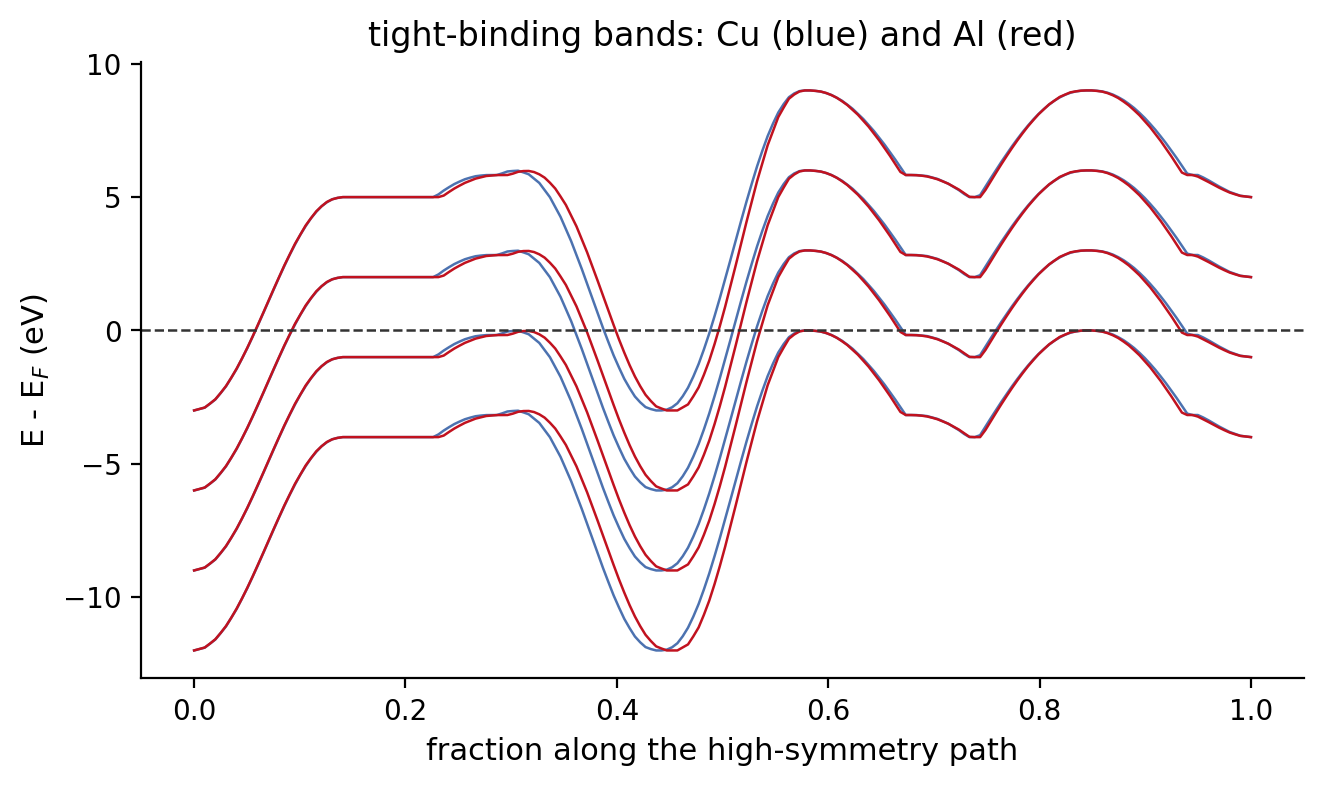

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4))
fraction = bands.var["path_fraction"].to_numpy(dtype=float)
for name, colour in zip(metals.obs_names, ("#4c72b0", "#c1121f")):
    block = np.asarray(bands[bands.obs["material"] == str(name)].X, dtype=float)
    for row in block:
        ax.plot(fraction, row, color=colour, linewidth=0.9)
ax.axhline(0, linestyle="--", color="#333", linewidth=0.9)
ax.set_xlabel("fraction along the high-symmetry path")
ax.set_ylabel("E - E$_F$ (eV)")
ax.set_title("tight-binding bands: Cu (blue) and Al (red)")

## What the bands say

Scalars derived from the bands land back on the material axis — the same move
`mv.multi.aggregate` makes for per-atom data.

In [20]:
mv.elec.band_features(bands, metals, level="tb")

metals.obs[["name", "band_gap_tb", "vbm_tb", "cbm_tb",
            "is_direct_tb", "is_metal_tb", "n_bands_tb"]].round(3)

,name,band_gap_tb,vbm_tb,cbm_tb,is_direct_tb,is_metal_tb,n_bands_tb
0,Cu,0.0,0.0,NaN,False,True,4
1,Al,0.0,0.0,NaN,False,True,4


Metals, gap zero. Correct: two of the four bands cross the Fermi level, and a
material with any band crossing E_F is a metal — not a semiconductor with a
negative gap, which is what a naive VBM-minus-CBM would report.

Build a gapped model and the same function finds the gap it was given:

In [21]:
def semiconductor(structure, gap=1.7, spacing=2.0, n_each=2):
    """Valence bands pushed to touch 0; conduction bands pushed to touch gap."""
    path = HighSymmKpath(structure)
    kpoints, _ = path.get_kpoints(line_density=8, coords_are_cartesian=False)
    k = np.asarray(kpoints, dtype=float)
    d = -2.0 * (np.cos(2 * np.pi * k[:, 0]) + np.cos(2 * np.pi * k[:, 1])
                + np.cos(2 * np.pi * k[:, 2]))

    rows = [d - d.max() - spacing * b for b in range(n_each)]
    rows += [-d + d.max() + gap + spacing * b for b in range(n_each)]
    return BandStructureSymmLine(
        kpoints, {Spin.up: np.vstack(rows)},
        structure.lattice.reciprocal_lattice, efermi=0.0,
        labels_dict=dict(path.kpath["kpoints"]), structure=structure)


gapped = mv.elec.bands(metals, [semiconductor(s)
                                for s in mv.structures(metals)],
                       level="model")
mv.elec.band_features(gapped, metals, level="model")

metals.obs[["name", "band_gap_model", "vbm_model", "cbm_model",
            "is_direct_model", "is_metal_model"]].round(3)

,name,band_gap_model,vbm_model,cbm_model,is_direct_model,is_metal_model
0,Cu,1.7,0.0,1.7,True,False
1,Al,1.7,0.0,1.7,True,False


1.70 eV, which is exactly what the model was built with, and **direct** —
because inverting the conduction dispersion puts its minimum at the same
k-point as the valence maximum. Directness is a k-point comparison, not a
property of the gap size, and it decides whether a material can absorb light
efficiently.

```{warning}
Semilocal DFT underestimates gaps by roughly half. `band_features` reports what
the bands say and does not correct them — the **level name** is what tells a
later reader whether a correction is needed, which is why `band_gap_pbe` and
`band_gap_hse06` are different columns rather than one column with a footnote.
```

## From a real DFT run

With actual output files the whole section above is two calls:

```python
mv.dft.write_inputs(md, 'runs/', preset='bands')
# ... the queue ...
bands = mv.elec.read_bands(md, 'runs/', level='pbe')
mv.elec.band_features(bands, md, level='pbe')
```

A run that produced no parseable band structure becomes a missing row with the
reason in `obs['band_error_pbe']`, never a silently dropped material.

### Density of states, as a fingerprint

`mv.dft.read_dos` puts a DOS on a shared energy grid;
`mv.elec.dos_fingerprint` reduces it to a fixed-length descriptor so two
electronic structures can be compared with a distance rather than by eye.

```python
mv.dft.read_dos(md, 'runs/', level='pbe')
mv.elec.dos_fingerprint(md, level='pbe', window=5.0, n_bins=32)
mv.feat.similarity(md, block='dos_fingerprint_pbe')
```

Binned over a window around E_F, because everything several eV away is deep
valence structure that no property depends on and would swamp the part that
does.

### Bonding analysis

`mv.elec.cohp` reads LOBSTER's crystal orbital Hamilton populations — negative
is bonding, positive antibonding, and the magnitude is a bond strength in eV.
It is the closest thing electronic structure theory offers to a bond order you
can screen on.

```python
mv.elec.cohp(md, 'lobster_runs/', level='pbe')
mv.screen.filter(md, icohp_min_pbe__lt=-2.0)     # at least one strong bond
```

### Transport

`mv.elec.transport` wants BoltzTraP2, which links against netCDF and does not
build from a wheel everywhere.

In [22]:
try:
    mv.elec.transport(metals, bands, level="tb")
except (ImportError, NotImplementedError) as exc:
    print(f"{type(exc).__name__}: {exc}")

ImportError: mv.elec.transport needs BoltzTraP2, which links against netCDF and often will not build from a wheel. Try `conda install -c conda-forge boltztrap2`, or compute the Seebeck coefficient from the bands yourself — mv.elec.band_features gives you the edges.


It names the install rather than returning zeros — and the docstring says why
the Seebeck coefficient is the number to trust: the conductivity comes out as
**σ/τ**, because the constant relaxation time approximation cannot supply τ.
Multiplying by a guessed τ is how thermoelectric screens produce figures of
merit that do not survive measurement.

## What both objects remember

In [23]:
for step in mv.provenance(sites):
    print(step)

multi.sites(source='input', n_materials=1)
env.coordination(strategy='crystalnn', source='input')
env.chemenv(source='input', max_csm=8.0)
env.bonds(strategy='crystalnn', source='input')


```{seealso}
[Chemical space](chemical_space.ipynb) is the composition side of the same
question — and the reason this page exists is everything composition cannot
reach. [Beyond one number](beyond_one_number.ipynb) introduces the sites axis
that `mv.env` writes into.
```